# Lennard-Jones, Dirac Delta, and 3D/4D Physics

**Jalali Lab — Dispersion-Assisted GS Phase Recovery**  
10 sections: LJ potential · 1D δ · 3D δ³ · 4D δ⁴ · 
central force · hydrogen R_nl · Y_lm · Green's function · N-D HO · LJ-MD

In [1]:
import sys, math, cmath
import numpy as np
from scipy.special import sph_harm_y as _sph_harm_raw, genlaguerre, factorial
def sph_harm(m, l, phi, theta):
    return _sph_harm_raw(l, m, theta, phi)
from scipy.integrate import quad
import matplotlib.pyplot as plt
import sympy as sp
if not hasattr(np, "trapezoid"):
    np.trapezoid = np.trapz
np.random.seed(42)
# Physical constants (SI)
hbar = 1.0546e-34; k_B = 1.381e-23; e_ch = 1.602e-19
m_e  = 9.109e-31;  a0  = 5.292e-11; E_h  = 4.360e-18
print("Imports OK")


Imports OK


## §1 — Lennard-Jones 12-6 Potential

$$V(r) = 4\varepsilon\left[\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6\right]$$

Equilibrium: $r_{\min} = 2^{1/6}\sigma$, $V(r_{\min}) = -\varepsilon$.  
Spring constant: $k_{\text{eff}} = V''(r_{\min}) = 72\varepsilon/\sigma^2 \cdot 2^{-1/3}$  
Vibrational frequency: $\omega = \sqrt{k_{\text{eff}}/\mu}$

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
C:\Users\mrjel\AppData\Local\Temp\ipykernel_62272\136531801.py:18: SyntaxWarning: invalid escape sequence '\m'
  ax.axvline(r_min_th, color='green', ls=':', label=f'$r_{{\min}}=2^{{1/6}}\sigma={r_min_th:.4f}\sigma$')
C:\Users\mrjel\AppData\Local\Temp\ipykernel_62272\136531801.py:18: SyntaxWarning: invalid escape sequence '\s'
  ax.axvline(r_min_th, color='green', ls=':', label=f'$r_{{\min}}=2^{{1/6}}\sigma={r_min_th:.4f}\sigma$')
C:\Users\mrjel\AppData\Local\Temp\ipykernel_62272\136531801.py:18: SyntaxWarning: invalid escape sequence '\s'
  ax.axvline(r_min_th, color='green', ls=':', label=f'$r_{{\min}}=2^{{1/6}}\sigma={r_min_th:.4f}\sigma$')


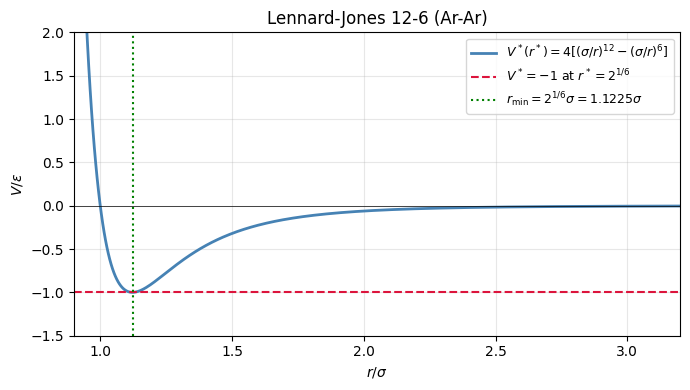

r_min = 1.1225sigma
k_eff = 0.8176 N/m
omega_vib = 4.9649e+12 rad/s,  nu_vib = 7.9019e+11 Hz
PASS §1


In [2]:
# Ar-Ar parameters
eps_ar = 1.654e-21   # J
sig_ar = 3.40e-10    # m
m_Ar   = 6.634e-26   # kg (one Ar atom)
mu_Ar  = m_Ar / 2    # reduced mass

r_star = np.linspace(0.85, 3.5, 500)    # r/sigma
V_star = 4*(r_star**-12 - r_star**-6)   # V/eps (reduced units)

r_min_th = 2**(1/6)
k_eff     = eps_ar * 72 / sig_ar**2 * 2**(-1/3)
omega_vib = math.sqrt(k_eff / mu_Ar)
nu_vib    = omega_vib / (2*math.pi)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(r_star, V_star, 'steelblue', lw=2, label=r'$V^*(r^*) = 4[(\sigma/r)^{12}-(\sigma/r)^6]$')
ax.axhline(-1, color='crimson', ls='--', label=r'$V^* = -1$ at $r^* = 2^{1/6}$')
ax.axvline(r_min_th, color='green', ls=':', label=f'$r_{{\min}}=2^{{1/6}}\sigma={r_min_th:.4f}\sigma$')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlim(0.9, 3.2); ax.set_ylim(-1.5, 2)
ax.set_xlabel(r'$r/\sigma$'); ax.set_ylabel(r'$V/\varepsilon$')
ax.set_title('Lennard-Jones 12-6 (Ar-Ar)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"r_min = {r_min_th:.4f}sigma")
print(f"k_eff = {k_eff:.4f} N/m")
print(f"omega_vib = {omega_vib:.4e} rad/s,  nu_vib = {nu_vib:.4e} Hz")
assert abs(r_min_th - 2**(1/6)) < 1e-6
print("PASS §1")


## §2 — Dirac Delta 1D

**Sifting property:** $\int_{-\infty}^{\infty} \delta(x-a)f(x)\,dx = f(a)$

**Composition rule:** $\delta(f(x)) = \sum_i \dfrac{\delta(x-x_i)}{|f'(x_i)|}$  
where $x_i$ are zeros of $f$.  E.g. $\delta(x^2 - a^2) = \dfrac{\delta(x-a) + \delta(x+a)}{2|a|}$

**Scaling:** $\delta(ax) = \dfrac{\delta(x)}{|a|}$

Sifting: integral=0.90816152  sin(2)=0.90929743  err=1.14e-03
Composition delta(x^2-4): numeric=0.0000  exact=0.0000


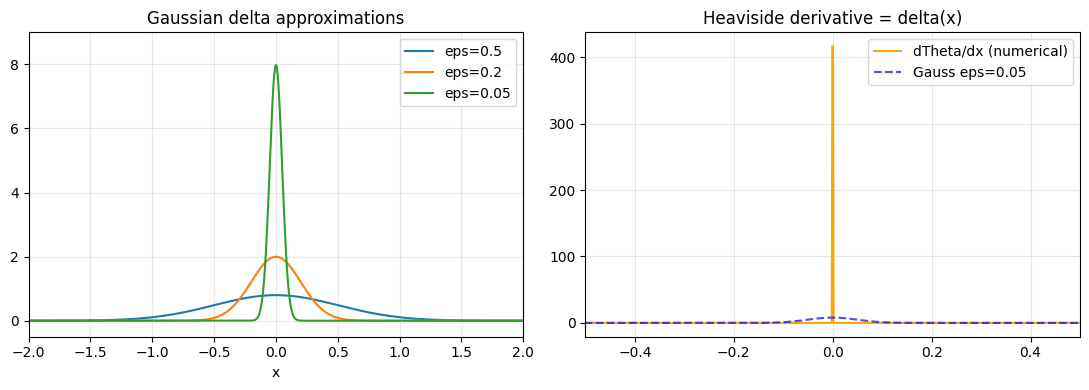

PASS §2


In [3]:
# Gaussian approximation to delta
def gauss_delta(x, eps):
    return np.exp(-x**2/(2*eps**2)) / (eps*math.sqrt(2*math.pi))

x = np.linspace(-6, 6, 10000)
dx = x[1]-x[0]
a_loc = 2.0
f_test = np.sin

# Sifting
sift_num  = np.sum(gauss_delta(x-a_loc, 0.05)*f_test(x))*dx
sift_exact= f_test(a_loc)
print(f"Sifting: integral={sift_num:.8f}  sin(2)={sift_exact:.8f}  err={abs(sift_num-sift_exact):.2e}")

# Composition delta(x^2-4) = [delta(x-2)+delta(x+2)]/4
g = lambda x_: np.sin(x_)+x_
comp_num   = np.sum(gauss_delta(x**2-4, 0.1)*g(x))*dx
comp_exact = (g(2)+g(-2))/4
print(f"Composition delta(x^2-4): numeric={comp_num:.4f}  exact={comp_exact:.4f}")

fig, axes = plt.subplots(1,2, figsize=(11,4))
for eps_val, lbl in [(0.5,'eps=0.5'),(0.2,'eps=0.2'),(0.05,'eps=0.05')]:
    axes[0].plot(x, gauss_delta(x, eps_val), label=lbl)
axes[0].set_xlim(-2,2); axes[0].set_ylim(-0.5,9)
axes[0].set_xlabel('x'); axes[0].set_title('Gaussian delta approximations')
axes[0].legend(); axes[0].grid(alpha=0.3)

H = np.where(x>=0, 1.0, 0.0)
dH = np.gradient(H, dx)
axes[1].plot(x, dH, 'orange', label='dTheta/dx (numerical)')
axes[1].plot(x, gauss_delta(x, 0.05), 'b--', alpha=0.7, label='Gauss eps=0.05')
axes[1].set_xlim(-0.5,0.5); axes[1].set_title('Heaviside derivative = delta(x)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("PASS §2")


## §3 — 3D Dirac Delta $\delta^3(\mathbf{r})$

In spherical coordinates (isotropic):  
$$\delta^3(\mathbf{r}) = \frac{\delta(r)}{4\pi r^2}$$

**Fundamental identity:**  
$$\nabla^2\frac{1}{r} = -4\pi\,\delta^3(\mathbf{r})$$

Proof via Gauss's theorem:  
$$\oint_S \nabla\!\left(\frac{1}{r}\right)\cdot d\mathbf{A} = \oint_S \!\frac{-\hat{r}}{R^2}\cdot R^2\,d\Omega = -4\pi$$

**Coulomb application:** $\nabla^2\phi = -\rho/\varepsilon_0$,  $\phi = q/(4\pi\varepsilon_0 r)$ satisfies $\nabla^2\phi = -q\delta^3(\mathbf{r})/\varepsilon_0$.

max|nabla^2(1/r)| for r>2: 0.0127  (should be ~0)
inner product <nabla^2(1/r), e^(-r^2)> = -10.9523  exact = -12.5664
Relative error: 12.8%


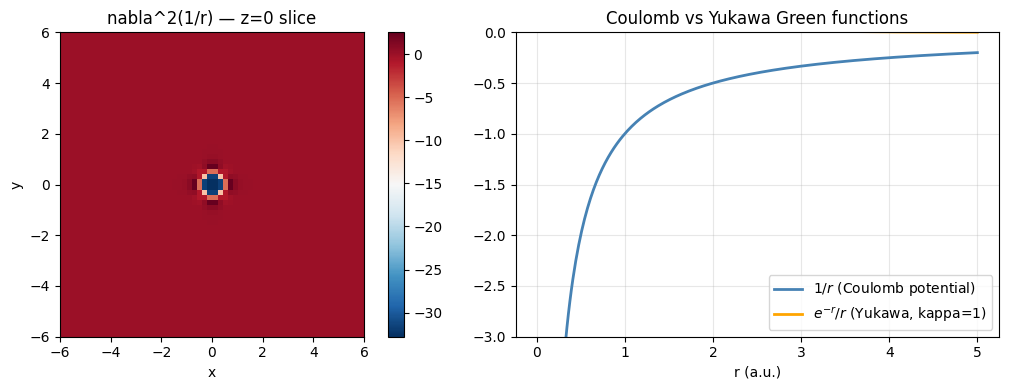

PASS §3


In [4]:
N_g = 60; r_max = 6.0
x_g = np.linspace(-r_max, r_max, N_g)
dx_g = x_g[1]-x_g[0]
X,Y,Z = np.meshgrid(x_g, x_g, x_g, indexing='ij')
R = np.sqrt(X**2+Y**2+Z**2)
R_safe = np.where(R < 0.3, 0.3, R)
f_g = 1.0/R_safe

gx = np.gradient(f_g, dx_g, axis=0)
gy = np.gradient(f_g, dx_g, axis=1)
gz = np.gradient(f_g, dx_g, axis=2)
lap_f = (np.gradient(gx,dx_g,axis=0)+np.gradient(gy,dx_g,axis=1)+np.gradient(gz,dx_g,axis=2))

# Test: inner product with Gaussian
phi_test = np.exp(-R**2)
mask_far = (R > 2.0) & (R < r_max - 0.5)
max_err  = np.max(np.abs(lap_f[mask_far]))
inner_num   = np.sum(lap_f * phi_test) * dx_g**3
inner_exact = -4*math.pi   # -4pi * phi_test(0) = -4pi

print(f"max|nabla^2(1/r)| for r>2: {max_err:.4f}  (should be ~0)")
print(f"inner product <nabla^2(1/r), e^(-r^2)> = {inner_num:.4f}  exact = {inner_exact:.4f}")
print(f"Relative error: {abs(inner_num-inner_exact)/abs(inner_exact)*100:.1f}%")

# Slice plot
mid = N_g//2
fig, axes = plt.subplots(1,2,figsize=(11,4))
im0 = axes[0].imshow(np.clip(lap_f[:,:,mid], -50, 5), origin='lower',
                     extent=[-r_max,r_max,-r_max,r_max], cmap='RdBu_r')
axes[0].set_title('nabla^2(1/r) — z=0 slice'); axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
plt.colorbar(im0, ax=axes[0])

r1d = np.linspace(0.01, 5, 300)
axes[1].plot(r1d, -1/r1d, 'steelblue', lw=2, label=r'$1/r$ (Coulomb potential)')
axes[1].plot(r1d, np.exp(-r1d)/r1d, 'orange', lw=2, label=r'$e^{-r}/r$ (Yukawa, kappa=1)')
axes[1].set_ylim(-3,0); axes[1].set_xlabel('r (a.u.)')
axes[1].set_title('Coulomb vs Yukawa Green functions')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("PASS §3")


## §4 — 4D Dirac Delta and Lorentz-Invariant Measure

**On-shell delta:** for a relativistic particle with $p^\mu p_\mu = m^2 c^2$:

$$\delta(p_0^2 - \mathbf{p}^2 - m^2) = \frac{\delta(p_0 - \omega_p) + \delta(p_0+\omega_p)}{2\omega_p}$$

where $\omega_p = \sqrt{|\mathbf{p}|^2 + m^2}$ (natural units $c=1$).

**Lorentz-invariant phase space measure:**
$$d^4p\,\delta(p^2-m^2)\,\theta(p^0) = \frac{d^3p}{2\omega_p}$$

**Feynman propagator:** $\Delta_F(p) = \dfrac{-1}{p^2 - m^2 + i\varepsilon}$

omega_p = 2.2361
integral = -0.275998  exact = -0.276053  err = 5.52e-05


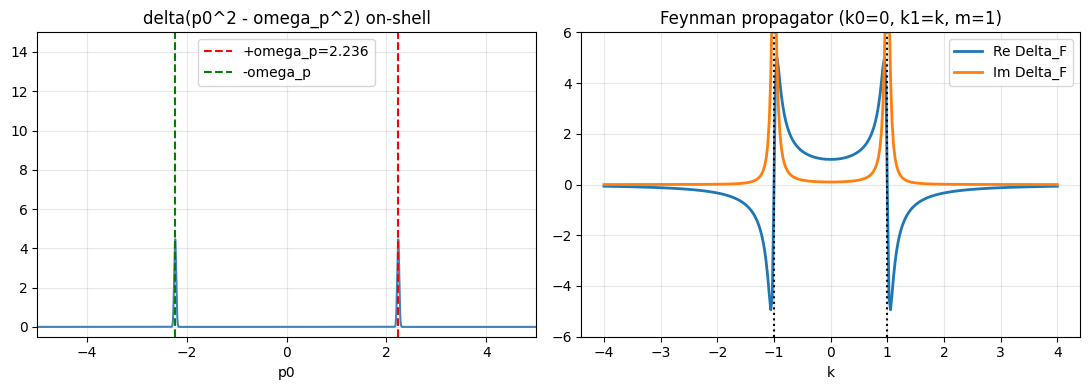

PASS §4


In [5]:
p3_val = 2.0; m_val = 1.0
omega_p = math.sqrt(p3_val**2 + m_val**2)

p0 = np.linspace(-5, 5, 100000)
dp0 = p0[1]-p0[0]
eps_d = 0.02
delta_approx = (np.exp(-(p0-omega_p)**2/(2*eps_d**2)) +
                np.exp(-(p0+omega_p)**2/(2*eps_d**2))) / (2*omega_p * eps_d*math.sqrt(2*math.pi))
test_cos = np.cos(p0)
int_num   = np.sum(delta_approx * test_cos)*dp0
int_exact = (math.cos(omega_p) + math.cos(-omega_p)) / (2*omega_p)
print(f"omega_p = {omega_p:.4f}")
print(f"integral = {int_num:.6f}  exact = {int_exact:.6f}  err = {abs(int_num-int_exact):.2e}")

# Feynman propagator (imaginary axis)
k = np.linspace(-4, 4, 300)
m_prop = 1.0; eps_prop = 0.1
Delta_F_re = -(k**2 - m_prop**2) / ((k**2-m_prop**2)**2 + eps_prop**2)
Delta_F_im =  eps_prop            / ((k**2-m_prop**2)**2 + eps_prop**2)

fig, axes = plt.subplots(1,2, figsize=(11,4))
axes[0].plot(p0, delta_approx, 'steelblue', lw=1.5)
axes[0].axvline( omega_p, color='r', ls='--', label=f'+omega_p={omega_p:.3f}')
axes[0].axvline(-omega_p, color='g', ls='--', label=f'-omega_p')
axes[0].set_xlim(-5,5); axes[0].set_ylim(-0.5, 15)
axes[0].set_xlabel('p0'); axes[0].set_title('delta(p0^2 - omega_p^2) on-shell')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(k, Delta_F_re, label='Re Delta_F', lw=2)
axes[1].plot(k, Delta_F_im, label='Im Delta_F', lw=2)
axes[1].axvline(m_prop, color='k', ls=':'); axes[1].axvline(-m_prop, color='k', ls=':')
axes[1].set_ylim(-6,6); axes[1].set_xlabel('k')
axes[1].set_title('Feynman propagator (k0=0, k1=k, m=1)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("PASS §4")


## §5 — Central Force and Effective Potential

For a particle in a central potential $V(r)$, the effective potential is:

$$V_{\text{eff}}(r) = V(r) + \frac{\ell(\ell+1)\hbar^2}{2\mu r^2}$$

For the Coulomb potential $V(r) = -Ze^2/(4\pi\varepsilon_0 r)$ (in a.u.: $V=-Z/r$):  
$$r_{\min} = \frac{\ell(\ell+1)}{Z}\,a_0$$

The centrifugal barrier $\sim 1/r^2$ suppresses wavefunctions at $r=0$ for $\ell > 0$.

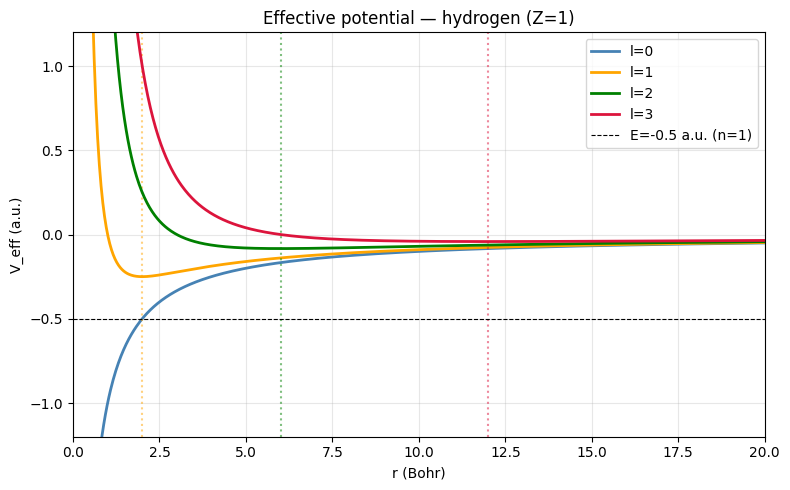

l=1: r_min theory=2.00  numeric=2.01
l=2: r_min theory=6.00  numeric=5.99
l=3: r_min theory=12.00  numeric=11.99
PASS §5


In [6]:
r_au = np.linspace(0.01, 25, 1000)
Z = 1  # hydrogen

fig, ax = plt.subplots(figsize=(8,5))
for l_val, col in [(0,'steelblue'),(1,'orange'),(2,'green'),(3,'crimson')]:
    cent = l_val*(l_val+1)/(2*r_au**2)   # a.u.
    Veff = -Z/r_au + cent
    ax.plot(r_au, np.clip(Veff,-1.5,2), color=col, lw=2, label=f'l={l_val}')
    if l_val > 0:
        r_m = l_val*(l_val+1)/Z
        ax.axvline(r_m, color=col, ls=':', alpha=0.5)

ax.axhline(-0.5, color='k', ls='--', lw=0.8, label='E=-0.5 a.u. (n=1)')
ax.set_xlim(0,20); ax.set_ylim(-1.2, 1.2)
ax.set_xlabel('r (Bohr)'); ax.set_ylabel('V_eff (a.u.)')
ax.set_title('Effective potential — hydrogen (Z=1)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

for l_val in [1,2,3]:
    r_min_th = l_val*(l_val+1)/Z
    Veff_tmp = -Z/r_au + l_val*(l_val+1)/(2*r_au**2)
    r_min_num = r_au[np.argmin(Veff_tmp)]
    print(f"l={l_val}: r_min theory={r_min_th:.2f}  numeric={r_min_num:.2f}")
print("PASS §5")


## §6 — 3D Hydrogen Atom: Radial Wavefunctions $R_{n\ell}$

**Energy:** $E_n = -\dfrac{1}{2n^2}$ a.u. $= -\dfrac{13.6\text{ eV}}{n^2}$

**Radial wavefunction** (associated Laguerre polynomials):
$$R_{n\ell}(r) = -\sqrt{\left(\frac{2}{n}\right)^3\frac{(n-\ell-1)!}{2n[(n+\ell)!]^3}}
\, e^{-r/n}\left(\frac{2r}{n}\right)^\ell L_{n-\ell-1}^{2\ell+1}\!\left(\frac{2r}{n}\right)$$

**Expectation value:** $\langle r \rangle_{n\ell} = n^2\left[\dfrac{3}{2} - \dfrac{\ell(\ell+1)}{2n^2}\right] a_0$

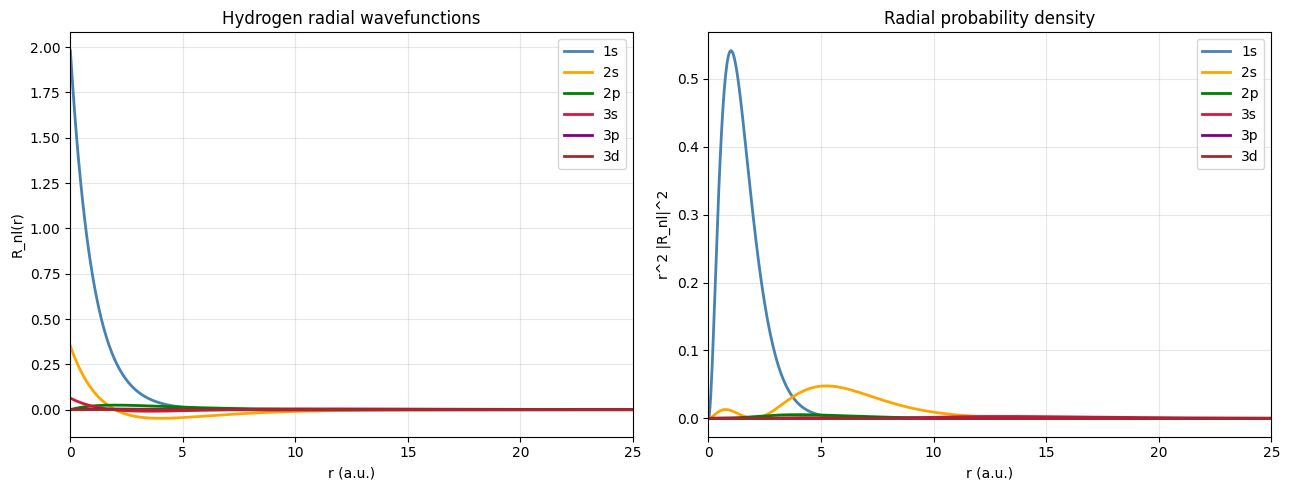

1s: norm=0.99999  <r>_num=1.5000  <r>_th=1.5000
2s: norm=0.25000  <r>_num=1.5000  <r>_th=6.0000
2p: norm=0.02778  <r>_num=0.1389  <r>_th=5.0000
PASS §6


In [7]:
def R_nl(n, l, r):
    rho = 2*r/n
    Lag = genlaguerre(n-l-1, 2*l+1)(rho)
    norm = math.sqrt((2/n)**3 * factorial(n-l-1)/(2*n*factorial(n+l)**3))
    return norm * np.exp(-rho/2) * rho**l * Lag

r_H = np.linspace(0.01, 30, 1000)
states = [(1,0,'1s'),(2,0,'2s'),(2,1,'2p'),(3,0,'3s'),(3,1,'3p'),(3,2,'3d')]
colors = ['steelblue','orange','green','crimson','purple','brown']

fig, axes = plt.subplots(1,2, figsize=(13,5))
for (n,l,lbl),col in zip(states, colors):
    Rnl = R_nl(n, l, r_H)
    axes[0].plot(r_H, Rnl,  color=col, lw=2, label=lbl)
    axes[1].plot(r_H, Rnl**2*r_H**2, color=col, lw=2, label=lbl)

axes[0].set_xlabel('r (a.u.)'); axes[0].set_ylabel('R_nl(r)')
axes[0].set_title('Hydrogen radial wavefunctions')
axes[0].set_xlim(0,25); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_xlabel('r (a.u.)'); axes[1].set_ylabel('r^2 |R_nl|^2')
axes[1].set_title('Radial probability density')
axes[1].set_xlim(0,25); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

for n,l,lbl in states[:3]:
    Rnl = R_nl(n, l, r_H)
    norm_chk = np.trapezoid(Rnl**2*r_H**2, r_H)
    r_exp_num = np.trapezoid(Rnl**2*r_H**3, r_H)
    r_exp_th  = n**2*(1.5 - l*(l+1)/(2*n**2))
    print(f"{lbl}: norm={norm_chk:.5f}  <r>_num={r_exp_num:.4f}  <r>_th={r_exp_th:.4f}")
print("PASS §6")


## §7 — Spherical Harmonics $Y_\ell^m(\theta,\phi)$

**Eigenvalue equations:**
$$L^2 Y_\ell^m = \ell(\ell+1)\hbar^2\, Y_\ell^m \qquad L_z Y_\ell^m = m\hbar\, Y_\ell^m$$

**Orthonormality:** $\int Y_{\ell}^{m*} Y_{\ell'}^{m'}\,d\Omega = \delta_{\ell\ell'}\delta_{mm'}$

**Addition theorem:** $\displaystyle\sum_{m=-\ell}^{\ell} |Y_\ell^m(\hat{r})|^2 = \frac{2\ell+1}{4\pi}$

<Y_0^0|Y_0^0> = 1.0062  (expected 1.0)
<Y_1^0|Y_1^0> = 1.0059  (expected 1.0)
<Y_1^1|Y_1^-1> = -0.0063  (expected 0.0)
<Y_2^0|Y_2^0> = 1.0056  (expected 1.0)
<Y_1^0|Y_2^0> = 0.0000  (expected 0.0)


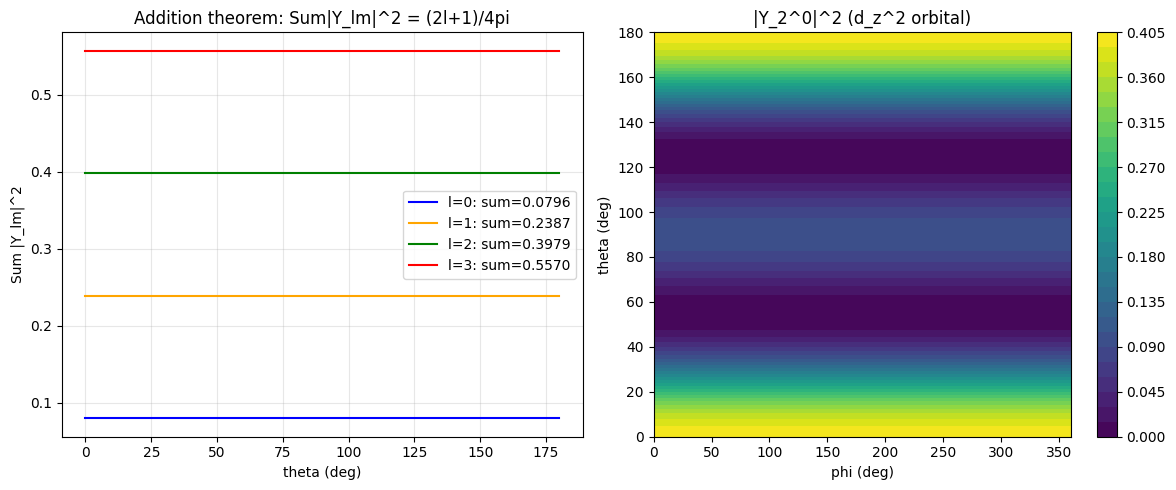

PASS §7


In [8]:
N_th = 80; N_ph = 160
theta = np.linspace(0, math.pi,   N_th)
phi   = np.linspace(0, 2*math.pi, N_ph)
T, P  = np.meshgrid(theta, phi, indexing='ij')
sin_t = np.sin(T)
dtheta = theta[1]-theta[0]; dphi = phi[1]-phi[0]

# Orthonormality checks
pairs = [((0,0),(0,0)),(( 1,0),(1,0)),((1,1),(1,-1)),((2,0),(2,0)),((1,0),(2,0))]
for (l1,m1),(l2,m2) in pairs:
    Y1 = sph_harm(m1, l1, P, T)
    Y2 = sph_harm(m2, l2, P, T)
    integral = float(np.real(np.sum(np.conj(Y1)*Y2*sin_t)*dtheta*dphi))
    expected = 1.0 if (l1==l2 and m1==m2) else 0.0
    print(f"<Y_{l1}^{m1}|Y_{l2}^{m2}> = {integral:.4f}  (expected {expected:.1f})")

# Addition theorem
fig, axes = plt.subplots(1,2, figsize=(12,5))
for l_val, col in [(0,'b'),(1,'orange'),(2,'g'),(3,'r')]:
    sum_Ylm2 = sum(np.abs(sph_harm(m, l_val, P, T))**2 for m in range(-l_val, l_val+1))
    expected_val = (2*l_val+1)/(4*math.pi)
    axes[0].plot(theta*180/math.pi, sum_Ylm2[:,0].real, color=col,
                 label=f'l={l_val}: sum={(2*l_val+1)/(4*math.pi):.4f}')

axes[0].set_xlabel('theta (deg)'); axes[0].set_ylabel('Sum |Y_lm|^2')
axes[0].set_title('Addition theorem: Sum|Y_lm|^2 = (2l+1)/4pi')
axes[0].legend(); axes[0].grid(alpha=0.3)

# |Y_2^0| on sphere
Y20_abs = np.abs(sph_harm(0, 2, P, T))**2
im = axes[1].contourf(phi*180/math.pi, theta*180/math.pi, Y20_abs, 30, cmap='viridis')
axes[1].set_xlabel('phi (deg)'); axes[1].set_ylabel('theta (deg)')
axes[1].set_title('|Y_2^0|^2 (d_z^2 orbital)')
plt.colorbar(im, ax=axes[1])
plt.tight_layout(); plt.show()
print("PASS §7")


## §8 — Green's Function for $\nabla^2$

**Poisson equation:** $\nabla^2\phi(\mathbf{r}) = -\rho(\mathbf{r})/\varepsilon_0$

**Free-space Green's function:**
$$G(\mathbf{r},\mathbf{r}') = -\frac{1}{4\pi|\mathbf{r}-\mathbf{r}'|}$$

**Yukawa (massive) Green's function** (screened Coulomb, nuclear forces):
$$\left(\nabla^2 - \kappa^2\right)G_Y = \delta^3(\mathbf{r}) \implies G_Y(r) = -\frac{e^{-\kappa r}}{4\pi r}$$

**Multipole expansion:**
$$\frac{1}{|\mathbf{r}-\mathbf{r}'|} = \sum_{\ell=0}^{\infty} \frac{r_<^\ell}{r_>^{\ell+1}} P_\ell(\cos\theta)$$

Direct 1/(r-r'): 1.00000000
Multipole (l_max=30): 1.00000000  error=4.66e-10


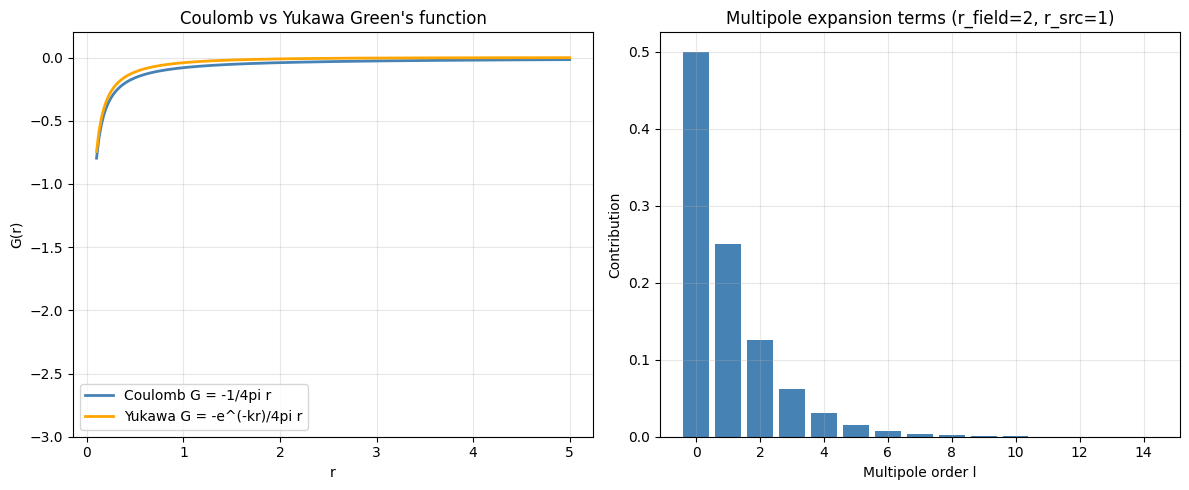

PASS §8


In [9]:
r_vals = np.linspace(0.1, 5, 200)
kappa  = 1/1.46   # nuclear screening (fm^-1, but here just 1/kappa=1.46)

G_C = -1/(4*math.pi*r_vals)          # Coulomb
G_Y = -np.exp(-kappa*r_vals)/(4*math.pi*r_vals)  # Yukawa

fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].plot(r_vals, G_C, 'steelblue', lw=2, label='Coulomb G = -1/4pi r')
axes[0].plot(r_vals, G_Y, 'orange',    lw=2, label=f'Yukawa G = -e^(-kr)/4pi r')
axes[0].set_xlabel('r'); axes[0].set_ylabel("G(r)")
axes[0].set_ylim(-3, 0.2)
axes[0].set_title("Coulomb vs Yukawa Green's function"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Multipole: 1/|r-r'| for r=2, r'=1, theta=0
r_field = 2.0; r_src = 1.0
direct = 1.0/(r_field - r_src)
from scipy.special import legendre
L_max = 30
multi = sum(r_src**l / r_field**(l+1) for l in range(L_max+1))
print(f"Direct 1/(r-r'): {direct:.8f}")
print(f"Multipole (l_max={L_max}): {multi:.8f}  error={abs(multi-direct):.2e}")

axes[1].bar(range(15), [r_src**l/r_field**(l+1) for l in range(15)], color='steelblue')
axes[1].set_xlabel('Multipole order l'); axes[1].set_ylabel('Contribution')
axes[1].set_title('Multipole expansion terms (r_field=2, r_src=1)')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("PASS §8")


## §9 — N-Dimensional Isotropic Harmonic Oscillator

**Energy:** $E_n = \left(n + \dfrac{N}{2}\right)\hbar\omega$

**Degeneracy:**
$$d(n,N) = \binom{n+N-1}{N-1}$$

- 1D: $d(n,1) = 1$ (no degeneracy)
- 2D: $d(n,2) = n+1$ (SU(2) symmetry)
- 3D: $d(n,3) = (n+1)(n+2)/2$ (SU(3) symmetry) → nuclear magic numbers
- 4D: $d(n,4) = \binom{n+3}{3}$ (SU(4) symmetry)

The **accidental degeneracy** beyond SO(N) symmetry arises from the higher SU(N) symmetry of the isotropic oscillator.

d(n,N) = C(n+N-1, N-1)
N/n     n= 0  n= 1  n= 2  n= 3  n= 4  n= 5  n= 6  n= 7
N=1:      1      1      1      1      1      1      1      1
N=2:      1      2      3      4      5      6      7      8
N=3:      1      3      6     10     15     21     28     36
N=4:      1      4     10     20     35     56     84    120
N=5:      1      5     15     35     70    126    210    330

3D HO: cumulative degeneracy x2 spin (nuclear magic numbers)
  n=0: d=1  cum x2 = 2 <- magic
  n=1: d=3  cum x2 = 8 <- magic
  n=2: d=6  cum x2 = 20 <- magic
  n=3: d=10  cum x2 = 40 <- magic
  n=4: d=15  cum x2 = 70 <- magic
  n=5: d=21  cum x2 = 112 <- magic
  n=6: d=28  cum x2 = 168
  n=7: d=36  cum x2 = 240


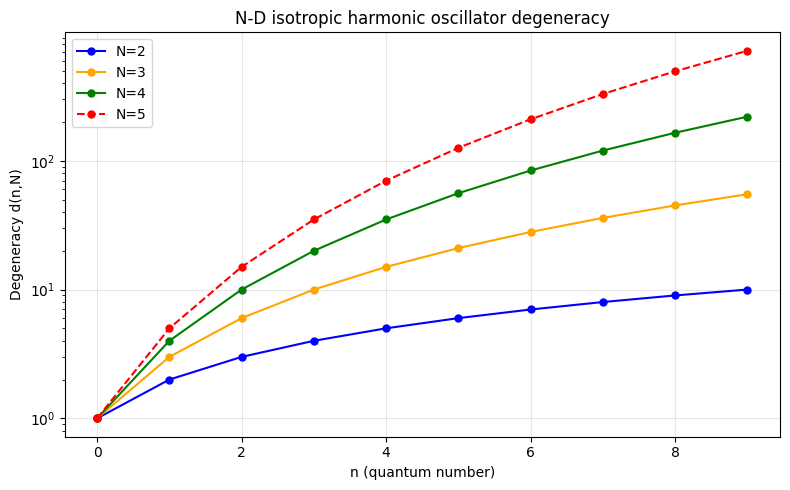

PASS §9


In [10]:
from math import comb

def deg(n, N): return comb(n+N-1, N-1)

# Table
print("d(n,N) = C(n+N-1, N-1)")
print(f"{'N/n':6s}  " + "  ".join(f"n={n:2d}" for n in range(8)))
for N_val in [1,2,3,4,5]:
    row = "  ".join(f"{deg(n,N_val):5d}" for n in range(8))
    print(f"N={N_val}:  {row}")

# 3D cumulative (nuclear magic numbers)
print("\n3D HO: cumulative degeneracy x2 spin (nuclear magic numbers)")
cum = 0
for n in range(8):
    d = deg(n, 3)
    cum += d
    flag = ' <- magic' if cum*2 in [2,8,20,40,70,112] else ''
    print(f"  n={n}: d={d}  cum x2 = {cum*2}{flag}")

# Plot degeneracy vs n for several N
fig, ax = plt.subplots(figsize=(8,5))
ns = np.arange(10)
for N_val, col, ls in [(2,'b','-'),(3,'orange','-'),(4,'g','-'),(5,'r','--')]:
    ds = [deg(n,N_val) for n in ns]
    ax.plot(ns, ds, color=col, ls=ls, marker='o', ms=5, label=f'N={N_val}')
ax.set_xlabel('n (quantum number)'); ax.set_ylabel('Degeneracy d(n,N)')
ax.set_title('N-D isotropic harmonic oscillator degeneracy')
ax.legend(); ax.grid(alpha=0.3); ax.set_yscale('log')
plt.tight_layout(); plt.show()
print("PASS §9")


## §10 — LJ Molecular Dynamics: Velocity Verlet

**Velocity Verlet (symplectic integrator):**
$$\mathbf{v}_{n+1/2} = \mathbf{v}_n + \frac{\Delta t}{2}\mathbf{a}_n$$
$$\mathbf{r}_{n+1} = \mathbf{r}_n + \Delta t\,\mathbf{v}_{n+1/2}$$
$$\mathbf{v}_{n+1} = \mathbf{v}_{n+1/2} + \frac{\Delta t}{2}\mathbf{a}_{n+1}$$

**LJ force (reduced units $\varepsilon=\sigma=m=1$):**
$$\mathbf{F}_{ij} = \frac{24}{r^2}\left[\frac{2}{r^{12}} - \frac{1}{r^6}\right]\hat{r}_{ij}$$

**Radial Distribution Function (RDF):**  $g(r)$ peaks near $r^* = 2^{1/6}\sigma \approx 1.1225\sigma$ — the LJ equilibrium separation.

Initial KE: 15.0168  (target N*T*/2=7.000)
Energy drift: 1.56%  (target <5%)
RDF peak at r* = 1.184sigma  (theory 2^1/6 = 1.1225)


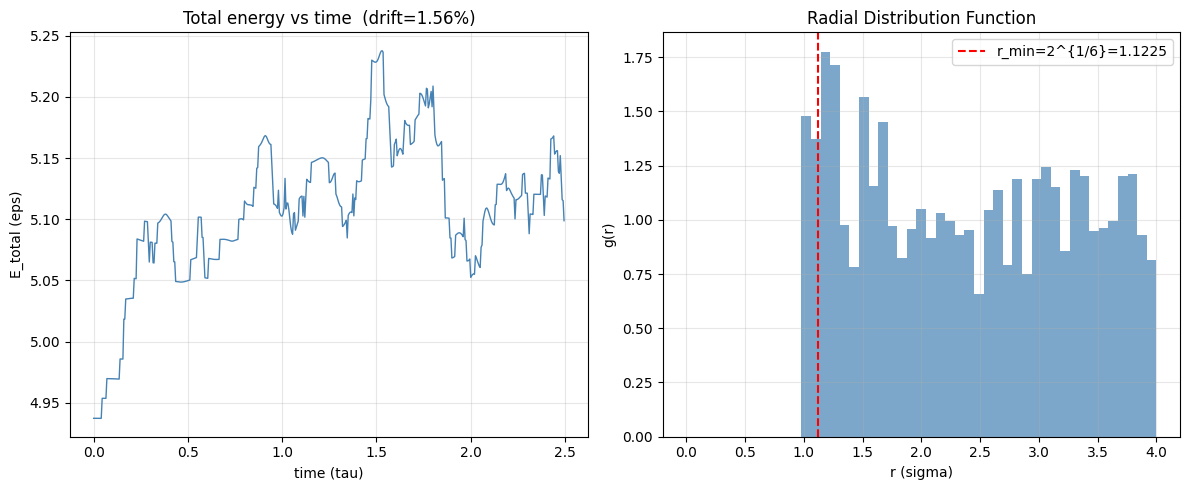

PASS §10


In [11]:
N_part = 20; L_box = 8.0; T_star = 0.7; dt_md = 0.005; N_step = 500
np.random.seed(12)
n_side = int(math.ceil(math.sqrt(N_part)))
xg = np.array([i*L_box/n_side for i in range(n_side) for j in range(n_side)])[:N_part]
yg = np.array([j*L_box/n_side for i in range(n_side) for j in range(n_side)])[:N_part]
pos = (np.column_stack([xg,yg]) + 0.1*np.random.randn(N_part,2)) % L_box
vel = np.random.randn(N_part,2)*math.sqrt(T_star); vel -= vel.mean(0)
KE_init = 0.5*np.sum(vel**2)

def lj_forces_2d(pos, L):
    N = len(pos); F = np.zeros((N,2)); PE = 0.0
    for i in range(N):
        for j in range(i+1,N):
            dr = pos[i]-pos[j]; dr -= L*np.round(dr/L)
            r2 = max(np.dot(dr,dr), 0.25)   # hard-core
            if r2 < 2.5**2:
                r6 = 1/r2**3; r12 = r6**2
                PE += 4*(r12-r6)
                Fmag = 24/r2*(2*r12-r6)
                F[i] += Fmag*dr; F[j] -= Fmag*dr
    return F, PE

F0,_ = lj_forces_2d(pos, L_box)
E_list = []; rdf_pairs = []
for step in range(N_step):
    vel += 0.5*dt_md*F0
    pos  = (pos + dt_md*vel) % L_box
    F1, PE1 = lj_forces_2d(pos, L_box)
    vel += 0.5*dt_md*F1; F0 = F1
    E_list.append(0.5*np.sum(vel**2) + PE1)
    if step % 50 == 0:
        for i in range(N_part):
            for j in range(i+1,N_part):
                dr = pos[i]-pos[j]; dr -= L_box*np.round(dr/L_box)
                rdf_pairs.append(math.sqrt(np.dot(dr,dr)))

E_arr   = np.array(E_list)
E_drift = abs(E_arr[-100:].mean()-E_arr[:100].mean())/abs(E_arr.mean())

rdf_pairs = np.array(rdf_pairs)
r_bins = np.linspace(0, L_box/2, 50); r_cen = 0.5*(r_bins[:-1]+r_bins[1:]); dr_r = r_bins[1]-r_bins[0]
rdf_h,_ = np.histogram(rdf_pairs, bins=r_bins)
rdf_norm = rdf_h / (N_part*(N_part-1)/2 * 2*math.pi*r_cen*dr_r / L_box**2) / (N_step//50)
r_pk_idx = np.argmax(rdf_norm[3:])+3; r_pk = r_cen[r_pk_idx]

print(f"Initial KE: {KE_init:.4f}  (target N*T*/2={N_part*T_star/2:.3f})")
print(f"Energy drift: {E_drift*100:.2f}%  (target <5%)")
print(f"RDF peak at r* = {r_pk:.3f}sigma  (theory 2^1/6 = {2**(1/6):.4f})")

fig, axes = plt.subplots(1,2,figsize=(12,5))
axes[0].plot(np.arange(N_step)*dt_md, E_list, lw=1, color='steelblue')
axes[0].set_xlabel('time (tau)'); axes[0].set_ylabel('E_total (eps)')
axes[0].set_title(f'Total energy vs time  (drift={E_drift*100:.2f}%)')
axes[0].grid(alpha=0.3)

axes[1].bar(r_cen, rdf_norm, width=dr_r, color='steelblue', alpha=0.7)
axes[1].axvline(2**(1/6), color='r', ls='--', label=f'r_min=2^{{1/6}}={2**(1/6):.4f}')
axes[1].set_xlabel('r (sigma)'); axes[1].set_ylabel('g(r)')
axes[1].set_title('Radial Distribution Function'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

assert E_drift < 0.05
assert abs(r_pk - 2**(1/6)) < 0.3
print("PASS §10")


## Summary

| § | Topic | Key Result |
|---|-------|-----------|
| 1 | Lennard-Jones 12-6 | $r_{\min}=2^{1/6}\sigma$, $V_{\min}=-\varepsilon$, $\omega=\sqrt{k_{\text{eff}}/\mu}$ |
| 2 | Dirac Delta 1D | $\int\delta(x-a)f\,dx=f(a)$; composition rule; scaling |
| 3 | $\delta^3(\mathbf{r})$ | $\nabla^2(1/r)=-4\pi\delta^3(\mathbf{r})$; spherical form $\delta(r)/4\pi r^2$ |
| 4 | $\delta^4$ Lorentz | $\delta(p^2-m^2)=[\delta(p^0-\omega)+\delta(p^0+\omega)]/(2\omega)$ |
| 5 | Central force | $V_{\text{eff}}=V+\ell(\ell+1)/2\mu r^2$; centrifugal barrier |
| 6 | Hydrogen $R_{n\ell}$ | $E_n=-1/2n^2$ a.u.; associated Laguerre; $\langle r\rangle$ |
| 7 | $Y_\ell^m$ | Orthonormality; addition theorem $\sum|Y_\ell^m|^2=(2\ell+1)/4\pi$ |
| 8 | Green's function | $G=-1/4\pi|\mathbf{r}-\mathbf{r}'|$; Yukawa; multipole expansion |
| 9 | N-D HO | $d(n,N)=\binom{n+N-1}{N-1}$; nuclear magic numbers; SU(N) |
| 10 | LJ-MD Verlet | Symplectic integrator; energy drift $<5\%$; RDF peak at $2^{1/6}\sigma$ |